In [1]:
import plotnado.api as pn
import coolbox.api as cb
import pathlib
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import pyranges as pr
import numpy as np
import re
from typing import List, Dict, Any, Tuple, Union, Literal, Optional

In [2]:
from plotnado.api import Figure, TrackWrapper, HighlightsFromFile

In [3]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["svg.fonttype"] = "none"

## Highlight the 'unique' enhancers

### Peaks

In [4]:
df_en_all = pd.read_csv(
    "/home/a/asmith/project_milne_group/Projects/2023-11-21-MLL-AF4_transcriptional_heterogeneity_paper/mll-af4_transcriptional_heterogeneity_paper/data/processed/find-enhancer-regions-in-patients/differential_enhancers.csv"
)

In [5]:
df_en_all.head()

,peak,bw1,is_higher,count,Chromosome,Start,End
0,chr12:9778941-9797455,chALL-26754-CM_H3K27ac.bw,True,8,chr12,9778941,9797455
1,chr2:43684095-43685551,CM-iALL87495_H3K27ac.bw,True,8,chr2,43684095,43685551
2,chr21:22960245-22962540,CM-iALL87495_H3K27ac.bw,True,8,chr21,22960245,22962540
3,chr2:2057650-2061569,CM-iALL87495_H3K27ac.bw,True,8,chr2,2057650,2061569
4,chr12:126965439-126967375,chALL-26754-CM_H3K27ac.bw,True,8,chr12,126965439,126967375


### All Enhancers

In [6]:
gr_peaks = pr.read_gtf(
    "/home/a/asmith/project_milne_group/Projects/enhancer_heterogeneity_paper/notebooks/classify_enhancers/gr_h3k27ac_consensus.gtf"
)

gr_peaks = gr_peaks.df[["Chromosome", "Start", "End", "Name"]].pipe(pr.PyRanges)
gr_peaks.df.shape

(13820, 4)

In [7]:
gr_peaks.df.assign(Name=" ")[["Chromosome", "Start", "End"]].to_csv(
    "peaks.bed", index=False, sep="\t", header=False
)

### Filter

In [8]:
df_en = df_en_all.query("count >= 7 and bw1.str.contains('26754')").sort_values(
    ["count", "bw1", "peak"], ascending=[False, True, True]
)
df_en

,peak,bw1,is_higher,count,Chromosome,Start,End
34,chr12:126949140-126951153,chALL-26754-CM_H3K27ac.bw,True,8,chr12,126949140,126951153
51,chr12:126960310-126962039,chALL-26754-CM_H3K27ac.bw,True,8,chr12,126960310,126962039
4,chr12:126965439-126967375,chALL-26754-CM_H3K27ac.bw,True,8,chr12,126965439,126967375
0,chr12:9778941-9797455,chALL-26754-CM_H3K27ac.bw,True,8,chr12,9778941,9797455
27,chr12:9807045-9809037,chALL-26754-CM_H3K27ac.bw,True,8,chr12,9807045,9809037
9,chr4:80109393-80111660,chALL-26754-CM_H3K27ac.bw,True,8,chr4,80109393,80111660
7,chr4:80194754-80195002,chALL-26754-CM_H3K27ac.bw,True,8,chr4,80194754,80195002
36,chr8:3175855-3178284,chALL-26754-CM_H3K27ac.bw,True,8,chr8,3175855,3178284
29,chr8:3184411-3187999,chALL-26754-CM_H3K27ac.bw,True,8,chr8,3184411,3187999
32,chr8:3190247-3192028,chALL-26754-CM_H3K27ac.bw,True,8,chr8,3190247,3192028


### Mark as unique with highlight

In [9]:
df_peaks = gr_peaks.df
df_peaks["Strand"] = "."
df_peaks["Score"] = 0
df_peaks

,Chromosome,Start,End,Name,Strand,Score
0,chr1,840725,842721,chr1:840725-842721,.,0
1,chr1,1065355,1066742,chr1:1065355-1066742,.,0
2,chr1,1122133,1122856,chr1:1122133-1122856,.,0
3,chr1,1143595,1145559,chr1:1143595-1145559,.,0
4,chr1,1209092,1209581,chr1:1209092-1209581,.,0
...,...,...,...,...,...,...
13815,chr22,50313828,50314818,chr22:50313828-50314818,.,0
13816,chr22,50398931,50400769,chr22:50398931-50400769,.,0
13817,chr22,50445175,50446198,chr22:50445175-50446198,.,0
13818,chr22,50468415,50472305,chr22:50468415-50472305,.,0


In [10]:
gr_peaks_unique = (
    df_peaks.loc[lambda df: df.Name.isin(df_en.peak)]
    .assign(Chromosome=lambda df: df.Chromosome.str.replace("chr", ""))
    .pipe(pr.PyRanges)
)
gr_peaks_unique.to_bed("peaks_unique.bed", keep=False)

# Files

### ChIP track order

chALL11911CMH3K27ac  
chALL11911CMMLLN	 
chALL20522H3K27ac	    
chALL20522MLLN	  
chALL26754CMH3K27ac	   
chALL26754CMMLLN	
chALL27800CMH3K27ac	   
chALL27800MLLN	 
iALL23003CMH3K27ac	  
iALL23003CMMLLN	    
iALL28349H3K27ac	     
iALL863388H3K27ac	      


In [57]:
patient_number_to_name = {
    "26754": "chALL1",
    "27654": "chALL1",
    "27800": "chALL2",
    "11911": "chALL3",
    "MA4-primograft": "iALL1",
    "2q23": "iALL2",
    "23003": "iALL2",
    "863388": "iALL3",
    "874415": "iALL4",
    "28349": "iALL5",
    "20522": "chALL4",
    "27800": "chALL5",
    "20522": "chALL6",
    "8011": "iALL6",
    "4484": "iALL7",
    "6807": "iALL8",
    "21940": "chALL7",
    "25911": "iALL9",
    "87495": "iALL4",
}

patient_sample_colors = {
    "chALL26754": "#e94d36",
    "chALL11911": "#fbbb10",
    "chALL20522": "#1e5df8",
    "chALL27800": "#67c04d",
    "iALL23003": "#be2bbb",
    "iALL28349": "#00a788",
    "iALL863388": "#ff9d1b",
    "iALL874415": "#4aa5dc",
    "chALL1": "#e94d36",
    "chALL2": "#67c04d",
    "chALL3": "#fbbb10",
    "chALL6": "#1e5df8",
    "chALL5": "#67c04d",
    "iALL2": "#be2bbb",
    "iALL5": "#00a788",
    "iALL3": "#ff9d1b",
    "iALL4": "#4aa5dc",
    "iALL1": "#33A69A",
    "iALL6": "#D93232",
    "iALL7": "#2E62A6",
    "iALL8": "#D99A25",
    'SEM': '#304190',
}

## ChIP tracks

In [12]:
chip_bigwigs_dir1 = pathlib.Path(
    "/home/a/asmith/project_milne_group/Projects/2023-11-21-MLL-AF4_transcriptional_heterogeneity_paper/mll-af4_transcriptional_heterogeneity_paper/data/raw/2024-04-02_chip_mll-af4-heterogeneity-paper-remap/seqnado_output/bigwigs"
)
chip_bigwigs_dir2 = pathlib.Path(
    "/ceph/project/milne_group/asmith/ChIP_seq/2023-11-01-ijun-chip-as-cm-cr-ct/2023-11-2-as-primary-and-cut-and-x/seqnado_output/bigwigs/deeptools"
)

chip_bigwigs = [
    *chip_bigwigs_dir1.rglob("*.bigWig"),
    *chip_bigwigs_dir2.glob("CM*.bigWig"),
]

chip_bigwigs[:5]

[PosixPath('/home/a/asmith/project_milne_group/Projects/2023-11-21-MLL-AF4_transcriptional_heterogeneity_paper/mll-af4_transcriptional_heterogeneity_paper/data/raw/2024-04-02_chip_mll-af4-heterogeneity-paper-remap/seqnado_output/bigwigs/deeptools/unscaled/iALL-28349_PAF1.bigWig'),
 PosixPath('/home/a/asmith/project_milne_group/Projects/2023-11-21-MLL-AF4_transcriptional_heterogeneity_paper/mll-af4_transcriptional_heterogeneity_paper/data/raw/2024-04-02_chip_mll-af4-heterogeneity-paper-remap/seqnado_output/bigwigs/deeptools/unscaled/iALL-863388_AF4-C.bigWig'),
 PosixPath('/home/a/asmith/project_milne_group/Projects/2023-11-21-MLL-AF4_transcriptional_heterogeneity_paper/mll-af4_transcriptional_heterogeneity_paper/data/raw/2024-04-02_chip_mll-af4-heterogeneity-paper-remap/seqnado_output/bigwigs/deeptools/unscaled/chALL-11911-CM_H3K4me1.bigWig'),
 PosixPath('/home/a/asmith/project_milne_group/Projects/2023-11-21-MLL-AF4_transcriptional_heterogeneity_paper/mll-af4_transcriptional_heterogene

### Categorise tracks

In [13]:
chip_tracks = pd.DataFrame(chip_bigwigs, columns=["path"])
chip_tracks["name"] = chip_tracks.path.apply(lambda x: x.stem)
chip_tracks["assay"] = np.where(chip_tracks.name.str.contains("ChIP"), "ChIP", "CM")
chip_tracks["patient"] = chip_tracks.name.str.extract(r"([0-9]+)")
chip_tracks["is_xeno"] = chip_tracks.name.str.contains("Xeno")
chip_tracks["antibody"] = (
    chip_tracks.name.str.replace("_(N|C)", r"-\1")
    .str.split("_")
    .str[-1]
    .str.replace("-\d$", "", regex=True)
    .str.replace("MLLN", "MLL-N")
)
chip_tracks["patient_name"] = chip_tracks.patient.map(patient_number_to_name)

chip_tracks[chip_tracks.antibody.str.contains("H3K27ac")]

# Filter the bigwigs to only include the ones we care about
chip_tracks = chip_tracks.query(
    "~is_xeno and ~antibody.isin(['C', 'N']) and assay == 'CM' and antibody.isin(['H3K27ac', 'MLL-N'])"
).drop_duplicates(subset=["patient_name", "antibody"])

chip_tracks = chip_tracks.sort_values(["patient_name", "antibody"])
chip_tracks

,path,name,assay,patient,is_xeno,antibody,patient_name
102,/home/a/asmith/project_milne_group/Projects/20...,chALL-26754-CM_H3K27ac,CM,26754,False,H3K27ac,chALL1
35,/home/a/asmith/project_milne_group/Projects/20...,chALL-26754-CM_MLLN,CM,26754,False,MLL-N,chALL1
13,/home/a/asmith/project_milne_group/Projects/20...,chALL-11911_H3K27ac,CM,11911,False,H3K27ac,chALL3
18,/home/a/asmith/project_milne_group/Projects/20...,chALL-11911-CM_MLL-N,CM,11911,False,MLL-N,chALL3
94,/home/a/asmith/project_milne_group/Projects/20...,chALL-27800-CM_H3K27ac,CM,27800,False,H3K27ac,chALL5
37,/home/a/asmith/project_milne_group/Projects/20...,chALL-27800_MLLN,CM,27800,False,MLL-N,chALL5
8,/home/a/asmith/project_milne_group/Projects/20...,chALL-20522_H3K27ac,CM,20522,False,H3K27ac,chALL6
27,/home/a/asmith/project_milne_group/Projects/20...,chALL-20522_MLL-N,CM,20522,False,MLL-N,chALL6
80,/home/a/asmith/project_milne_group/Projects/20...,chALL21940_H3K27ac,CM,21940,False,H3K27ac,chALL7
40,/home/a/asmith/project_milne_group/Projects/20...,iALL-23003-CM_H3K27ac,CM,23003,False,H3K27ac,iALL2


### Drop the poor quality tracks (iALL9)

In [14]:
chip_tracks = chip_tracks.query("~patient_name.isin(['iALL9'])")
chip_tracks

,path,name,assay,patient,is_xeno,antibody,patient_name
102,/home/a/asmith/project_milne_group/Projects/20...,chALL-26754-CM_H3K27ac,CM,26754,False,H3K27ac,chALL1
35,/home/a/asmith/project_milne_group/Projects/20...,chALL-26754-CM_MLLN,CM,26754,False,MLL-N,chALL1
13,/home/a/asmith/project_milne_group/Projects/20...,chALL-11911_H3K27ac,CM,11911,False,H3K27ac,chALL3
18,/home/a/asmith/project_milne_group/Projects/20...,chALL-11911-CM_MLL-N,CM,11911,False,MLL-N,chALL3
94,/home/a/asmith/project_milne_group/Projects/20...,chALL-27800-CM_H3K27ac,CM,27800,False,H3K27ac,chALL5
37,/home/a/asmith/project_milne_group/Projects/20...,chALL-27800_MLLN,CM,27800,False,MLL-N,chALL5
8,/home/a/asmith/project_milne_group/Projects/20...,chALL-20522_H3K27ac,CM,20522,False,H3K27ac,chALL6
27,/home/a/asmith/project_milne_group/Projects/20...,chALL-20522_MLL-N,CM,20522,False,MLL-N,chALL6
80,/home/a/asmith/project_milne_group/Projects/20...,chALL21940_H3K27ac,CM,21940,False,H3K27ac,chALL7
40,/home/a/asmith/project_milne_group/Projects/20...,iALL-23003-CM_H3K27ac,CM,23003,False,H3K27ac,iALL2


## Add the SEM tracks

In [40]:
h3k27ac_bigwigs = dict(
    control="/ceph/project/milne_group/asmith/ChIP_seq/2024-08-27-mll-af4-kd-remap/seqnado_output/bigwigs/SEM-siMM_H3K27ac.bigWig",
    knockdown="/ceph/project/milne_group/asmith/ChIP_seq/2024-08-27-mll-af4-kd-remap/seqnado_output/bigwigs/SEM-siMA6_H3K27ac.bigWig",
)

sem_archive_data = list(
    pathlib.Path(
        "/ceph/project/milne_group/shared/seqnado_archive/chip_seq/2024-02-01_chip_sem_archive/seqnado_output/bigwigs/deeptools/unscaled"
    ).glob("*.bigWig")
)
df_archive = pd.DataFrame(sem_archive_data, columns=["path"])
df_archive["name"] = df_archive.path.apply(lambda x: x.stem)
df_archive["antibody"] = df_archive.name.str.split("_").str[-1].str.upper()

# Filter the bigwigs to only include the ones we care about
df_archive = df_archive.query("antibody.isin(['MLLN', 'AF4C', 'H3K27AC']) and not name.str.contains('cells')")
df_archive

,path,name,antibody
134,/ceph/project/milne_group/shared/seqnado_archi...,sem-mlln_mlln,MLLN
140,/ceph/project/milne_group/shared/seqnado_archi...,sem-h3k27ac_h3k27ac,H3K27AC
145,/ceph/project/milne_group/shared/seqnado_archi...,sem-af4c_af4c,AF4C


# MCC

In [16]:
def get_sample_id(row: pd.Series, patient_mapping: dict):
    try:
        id_number = re.search(r"(\d+)", row.sample_id).group(1)
        name = patient_mapping[id_number]
    except Exception as e:
        name = row.sample_id

    return name

In [17]:
patient_dir = pathlib.Path(
    "/project/milne_group/ndenny/MCC/01_MLL_MCC/01_chALL_26754/03_analysis/"
)
sem_dir = pathlib.Path(
    "/project/milne_group/ndenny/MCC/01_MLL_MCC/02_SEM/202110_50_oligo_MCC_SEM_novogene/analysis/hg38/fifty_oligo_cap_hg38_combined"
)
dframes = []
for sample_id, path in zip(["SEM", "chALL26754"], [sem_dir, patient_dir]):
    df = pd.DataFrame(path.rglob("*_ext_de_norm_rep_*.bw"), columns=["path"]).assign(
        sample_id=sample_id
    )
    dframes.append(df)

df = pd.concat(dframes)
df["name"] = df["path"].apply(lambda x: x.stem)
df["sample_id"] = [get_sample_id(r, patient_number_to_name) for r in df.itertuples()]
df["viewpoint"] = df["name"].str.split("_").str[0]
df["is_tiled"] = df.name.str.contains("tiled")

df = df.drop_duplicates(subset=["sample_id", "viewpoint", "is_tiled"])
mcc_tracks = df.copy()
mcc_tracks.groupby(["sample_id", "is_tiled"]).size()

sample_id  is_tiled
SEM        False       45
chALL1     False       77
           True         4
dtype: int64

# Plot

In [18]:
VIEWPOINT = "MEIS1"

In [19]:
highlight = HighlightsFromFile(
    "peaks_unique.bed", color=patient_sample_colors["chALL1"], alpha=0.2
)

In [20]:
def get_color(x, sample_colors):
    return sample_colors.get(x, "black")

In [21]:
def get_mcc_from_promoter_track(
    df: pd.DataFrame, viewpoint: str, sample_name: Union[Literal["SEM", "chALL1"]]
) -> Optional[str]:
    df = df.query(f"viewpoint == '{viewpoint}' and sample_id == '{sample_name}'")

    if df.shape[0] > 1:
        print(f"Warning: More than one path found for {viewpoint} and {sample_name}")
    elif df.shape[0] == 0:
        print(f"Warning: No path found for {viewpoint} and {sample_name}")
        return None

    if df.is_tiled.any():
        path = df.query("is_tiled").path.iloc[0]
    else:
        path = df.path.iloc[0]

    return str(path)

# Load the MCC enhancer data

* Load the tracks
* Load the viewpoint locations
* For my examples assign these enhancers to the nearest gene so these can be plotted

In [22]:
bws_mcc_enhancers_path = pathlib.Path("/project/milne_group/ndenny/MCC/01_MLL_MCC/01_chALL_26754/04_tracks/26754_IDT_enhancer_capture/hg38")
bws_mcc_enhancers = [p for p in bws_mcc_enhancers_path.rglob("*_ext_de_norm_rep_*.bw")] 
df_mcc_enhancers = pd.DataFrame(bws_mcc_enhancers, columns=["path"]).assign(
    name=lambda x: x.path.apply(lambda y: y.stem),
    enhancer=lambda x: x.name.str.split("_").str[0],
)
df_mcc_enhancers.head()

,path,name,enhancer
0,/project/milne_group/ndenny/MCC/01_MLL_MCC/01_...,Enhancer9_ext_de_norm_rep_26754_IDT_enhancer_c...,Enhancer9
1,/project/milne_group/ndenny/MCC/01_MLL_MCC/01_...,Enhancer38_ext_de_norm_rep_26754_IDT_enhancer_...,Enhancer38
2,/project/milne_group/ndenny/MCC/01_MLL_MCC/01_...,Enhancer52_ext_de_norm_rep_26754_IDT_enhancer_...,Enhancer52
3,/project/milne_group/ndenny/MCC/01_MLL_MCC/01_...,Enhancer45_ext_de_norm_rep_26754_IDT_enhancer_...,Enhancer45
4,/project/milne_group/ndenny/MCC/01_MLL_MCC/01_...,Enhancer20_ext_de_norm_rep_26754_IDT_enhancer_...,Enhancer20


### Viewpoint locations

In [23]:
gr_viewpoints_enhancers = pr.read_bed('/project/milne_group/ndenny/MCC/01_MLL_MCC/01_chALL_26754/01_data/26754_IDT_enhancer_capture/enhancer.viewpoints')
gr_viewpoints_enhancers.head()

,Chromosome,Start,End,Name
0,chr2,66577620,66583680,Enhancer27
1,chr4,875977,876217,Enhancer33
2,chr4,877445,877805,Enhancer34
3,chr4,80110415,80110655,Enhancer35
4,chr6,45322533,45322893,Enhancer36
5,chr6,45323800,45324160,Enhancer37
6,chr6,45327976,45328456,Enhancer38
7,chr6,45331148,45331508,Enhancer39


In [24]:
gr_refseq = pr.read_gtf(
    "/project/milne_group/shared/seqnado_reference/hg38/UCSC/genes/hg38.ncbiRefSeq.gtf"
)

In [25]:
gr_tss = gr_refseq.features.tss()

In [26]:
gr_enhancers_to_genes = gr_viewpoints_enhancers.join(gr_tss.extend(int(2e5)))

join: Strand data from other will be added as strand data to self.
If this is undesired use the flag apply_strand_suffix=False.
To turn off the warning set apply_strand_suffix to True or False.


In [27]:
gr_enhancers_to_genes.sample(n=5)

,Chromosome,Start,End,Name,Source,Feature,Start_b,End_b,Score,Strand,Frame,gene_id,transcript_id,gene_name,exon_number,exon_id
0,chr4,877445,877805,Enhancer34,ncbiRefSeq.2022-10-28,tss,513170,913171,.,+,.,LOC124900172,XM_047416540.1,LOC124900172,NaN,NaN
1,chr4,877445,877805,Enhancer34,ncbiRefSeq.2022-10-28,tss,732459,1132460,.,+,.,TMEM175,NM_032326.4,TMEM175,NaN,NaN
2,chr4,875977,876217,Enhancer33,ncbiRefSeq.2022-10-28,tss,487344,887345,.,-,.,SLC49A3,XM_047416287.1,SLC49A3,NaN,NaN
3,chr6,45361477,45361777,Enhancer45,ncbiRefSeq.2022-10-28,tss,45122966,45522967,.,-,.,SUPT3H,XM_047419417.1,SUPT3H,NaN,NaN
4,chr20,17643764,17644124,Enhancer28,ncbiRefSeq.2022-10-28,tss,17499965,17899966,.,+,.,BANF2,XM_011529170.2,BANF2,NaN,NaN


In [28]:
enhancer_name_to_path_mapping = df_mcc_enhancers.set_index("enhancer").path.to_dict()

# Plot with the MCC

In [80]:
def make_figure(
    viewpoint: str,
    chip_tracks: pd.DataFrame,
    mcc_tracks: pd.DataFrame,
    colors: Dict[str, str],
    highlight: Optional[cb.HighLights] = None,
    min_gene_length: int = int(1.2e5),
    mcc_max_value: int = 5,
) -> Figure:
    fig = Figure(autospacing=True, highlight_regions=highlight if highlight else None)

    # Standard tracks
    fig.add_track("scale")
    fig.add_track(
        "genes",
        genome="hg38",
        gene_style="normal",
        min_gene_length=min_gene_length,
        height=0.5,
        label_y_offset=-75,
        label_loc="right",
        arrow_color="black",
    )

    fig.add_track(
        'spacer'
    )

    # MCC tracks
    if mcc_tracks is not None and not mcc_tracks.empty:
        sem_track = get_mcc_from_promoter_track(mcc_tracks, viewpoint=viewpoint, sample_name="SEM")
        patient_track = get_mcc_from_promoter_track(mcc_tracks, viewpoint=viewpoint, sample_name="chALL1")
    else:
        sem_track = None
        patient_track = None

    if sem_track:
        mcc_sem = TrackWrapper(
            "bigwig",
            sem_track,
            title="SEM MCC",
            color=patient_sample_colors["SEM"],
            style="stairsfilled",
            number_of_bins=1000,
            data_range_style="text",
            data_range_location="right",
            label_on_track=True,
            label_loc="left",
            max_value=mcc_max_value,
        )

        fig.add_track(mcc_sem)

    if patient_track:
        mcc_patient = TrackWrapper(
            "bigwig",
            get_mcc_from_promoter_track(mcc_tracks, viewpoint=viewpoint, sample_name="chALL1"),
            title="chALL1 MCC",
            color=colors["chALL1"],
            style="stairsfilled",
            number_of_bins=1000,
            data_range_style="text",
            data_range_location="right",
            label_on_track=True,
            label_loc="left",
            max_value=mcc_max_value,
        )
        fig.add_track(mcc_patient)

    # Enhancer tracks
    enhancers_to_plot = gr_enhancers_to_genes.df.query('gene_id == @viewpoint')['Name']
    enhancer_paths = {enhancer: enhancer_name_to_path_mapping[enhancer] for enhancer in enhancers_to_plot}

    for enhancer, enhancer_path in enhancer_paths.items():
        fig.add_track('spacer')
        fig.add_track(
            "bigwig",
            file=str(enhancer_path),
            style="stairsfilled",
            color=colors["chALL1"],
            title=enhancer,
            data_range_style="text",
            data_range_location="right",
            label_on_track=True,
            label_loc="left",
            max_value=mcc_max_value
        )


    # ChIP tracks
    for track in chip_tracks.itertuples():
        fig.add_track(
            "bigwig",
            file=str(track.path),
            style="stairsfilled",
            color=get_color(track.patient_name, colors),
            title=f"{track.patient_name} {track.antibody}",
            data_range_style="text",
            data_range_location="right",
            label_on_track=True,
            label_loc="left",
            autoscale_group=track.antibody,
        )

    # Add genomic axis
    fig.add_track("xaxis")

    return fig

2025-05-08 16:10:17.060 | DEBUG    | plotnado.api.genes:__get_length_w:49 - len of w set to: 2517.278123702781 bp
2025-05-08 16:10:17.082 | DEBUG    | plotnado.api.genes:plot_genes:206 - ylim 330.0,0


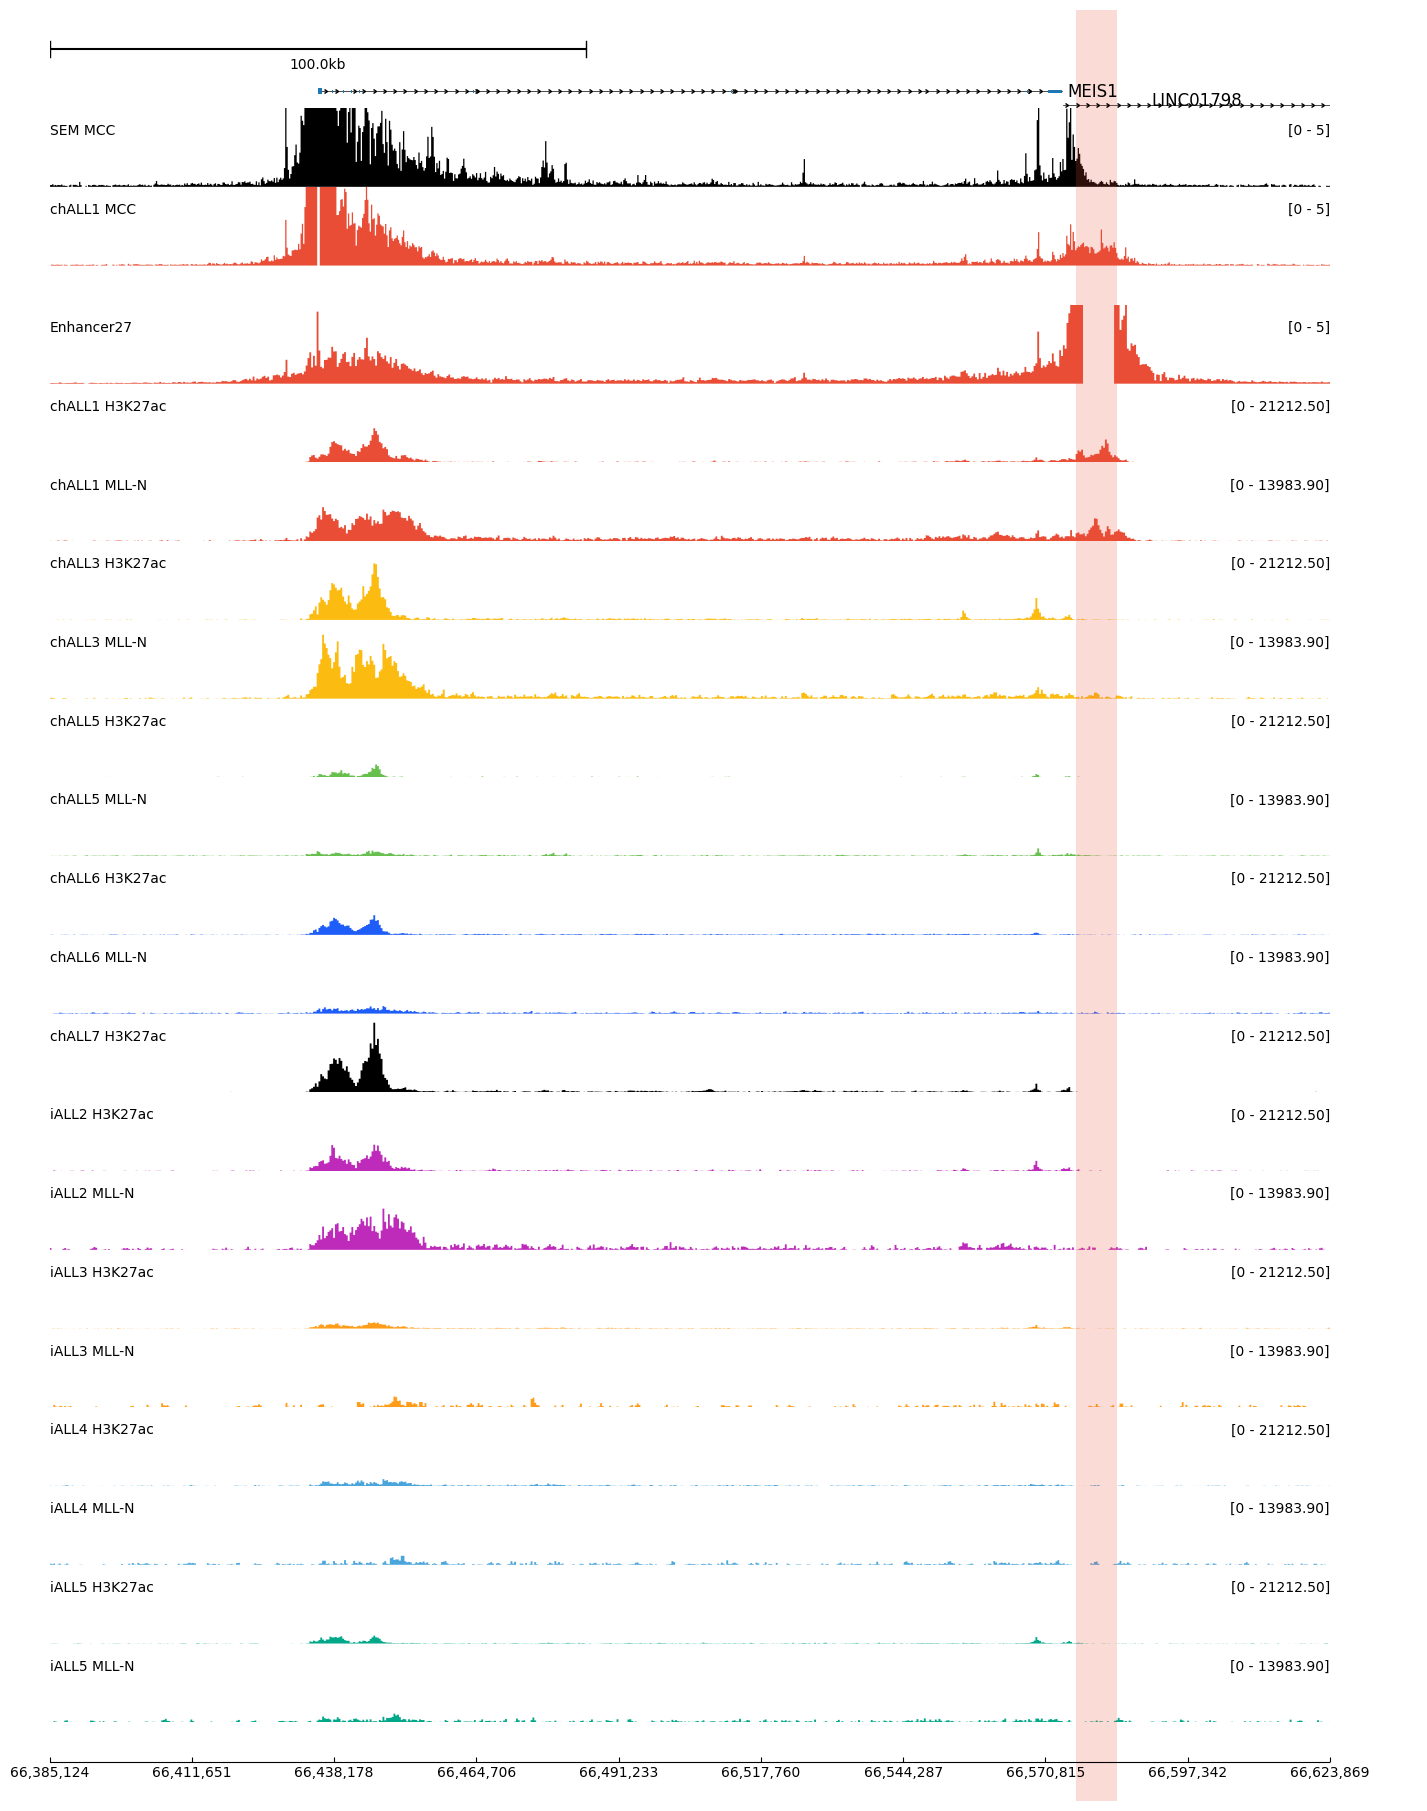

In [33]:
VIEWPOINT = "MEIS1"

fig = make_figure(VIEWPOINT, chip_tracks, mcc_tracks, patient_sample_colors, highlight)
f = fig.plot_gene(VIEWPOINT, "hg38", extend=int(5e4))
f

[ERROR:base.py:264 -       plot_coverages()] Error occured when plot track's coverage:
	track name: ScaleBar.4
	track type:<class 'plotnado.api.tracks.ScaleBar'>
	coverage name: HighlightsFromFile.1
	cov type: <class 'plotnado.api.tracks.HighlightsFromFile'>
	Error: <class 'KeyError'> '6'
[ERROR:base.py:269 -       plot_coverages()] '6'
Traceback (most recent call last):
  File "/ceph/project/milne_group/asmith/software/mambaforge/envs/ma4_th/lib/python3.10/site-packages/coolbox/core/track/base.py", line 262, in plot_coverages
    cov.plot(ax, copy(gr), gr2=copy(gr2))
  File "/ceph/project/milne_group/asmith/Projects/plotnado/plotnado/api/tracks.py", line 1415, in plot
    regions = self.fetch_data(gr, **kwargs)
  File "/ceph/project/milne_group/asmith/software/mambaforge/envs/ma4_th/lib/python3.10/site-packages/coolbox/core/coverage/highlights.py", line 24, in fetch_data
    self.interval_tree[gr.chrom][gr.start - 10000 : gr.end + 10000]
KeyError: '6'
2025-05-08 16:10:24.802 | DEBUG  

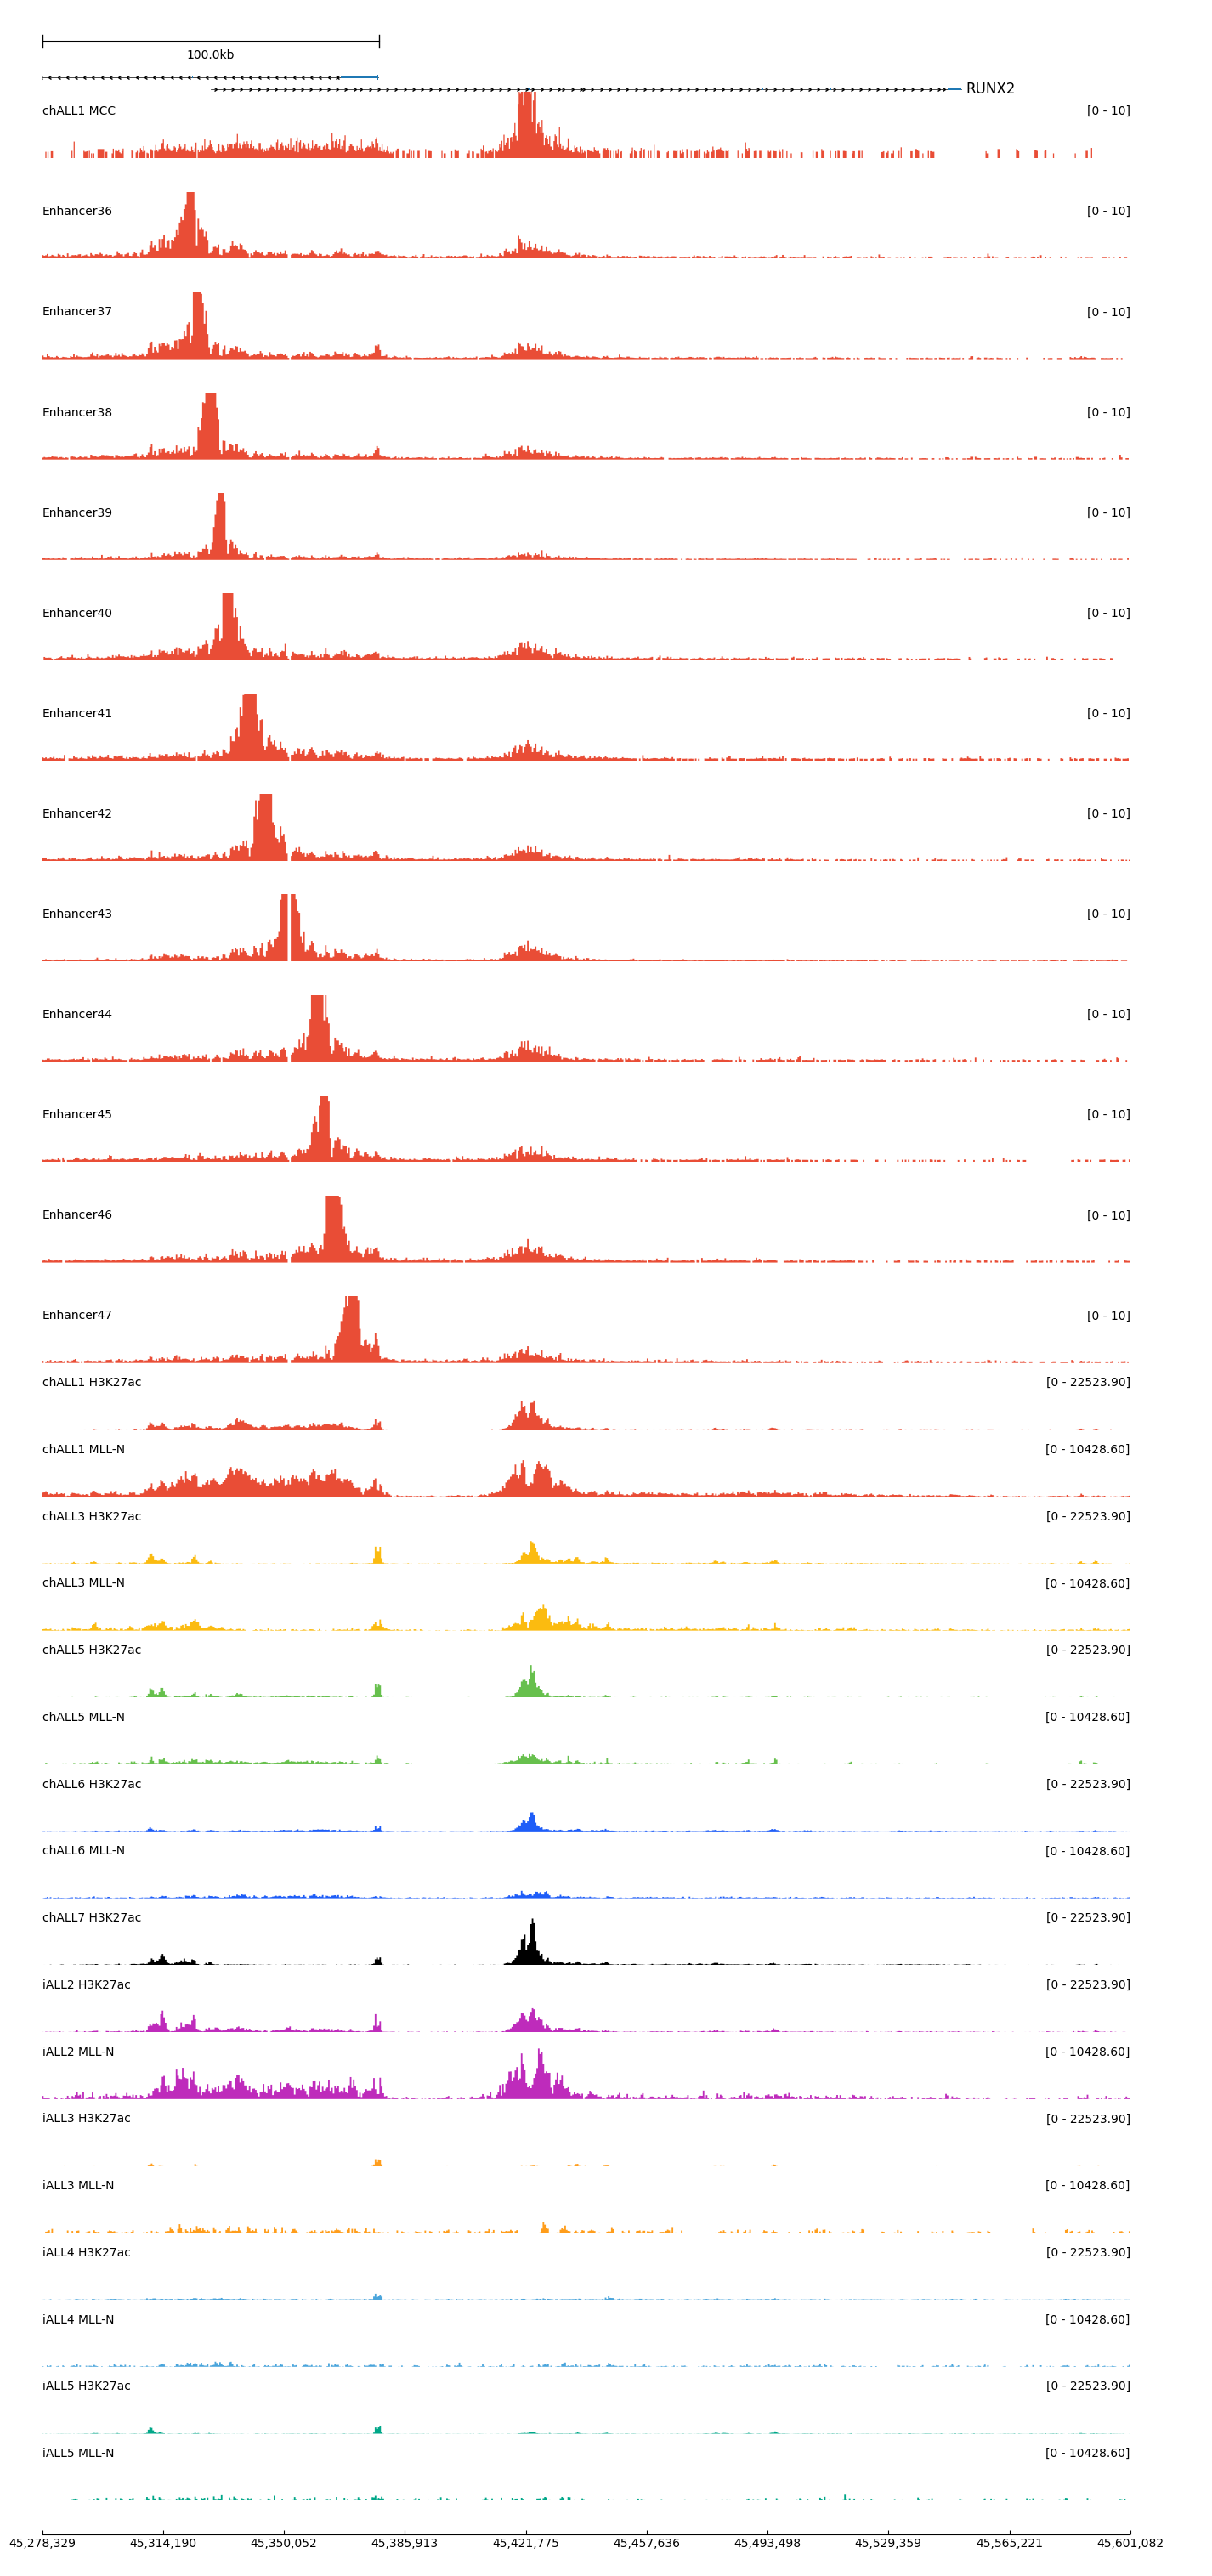

In [34]:
VIEWPOINT = "RUNX2"

fig = make_figure(VIEWPOINT, chip_tracks, mcc_tracks, patient_sample_colors, highlight, mcc_max_value=10)
f = fig.plot_gene(VIEWPOINT, "hg38", extend=int(5e4))
f

2025-05-08 16:10:34.174 | DEBUG    | plotnado.api.genes:__get_length_w:49 - len of w set to: 2197.495392278954 bp
2025-05-08 16:10:34.278 | DEBUG    | plotnado.api.genes:plot_genes:206 - ylim 789.9999999999999,0


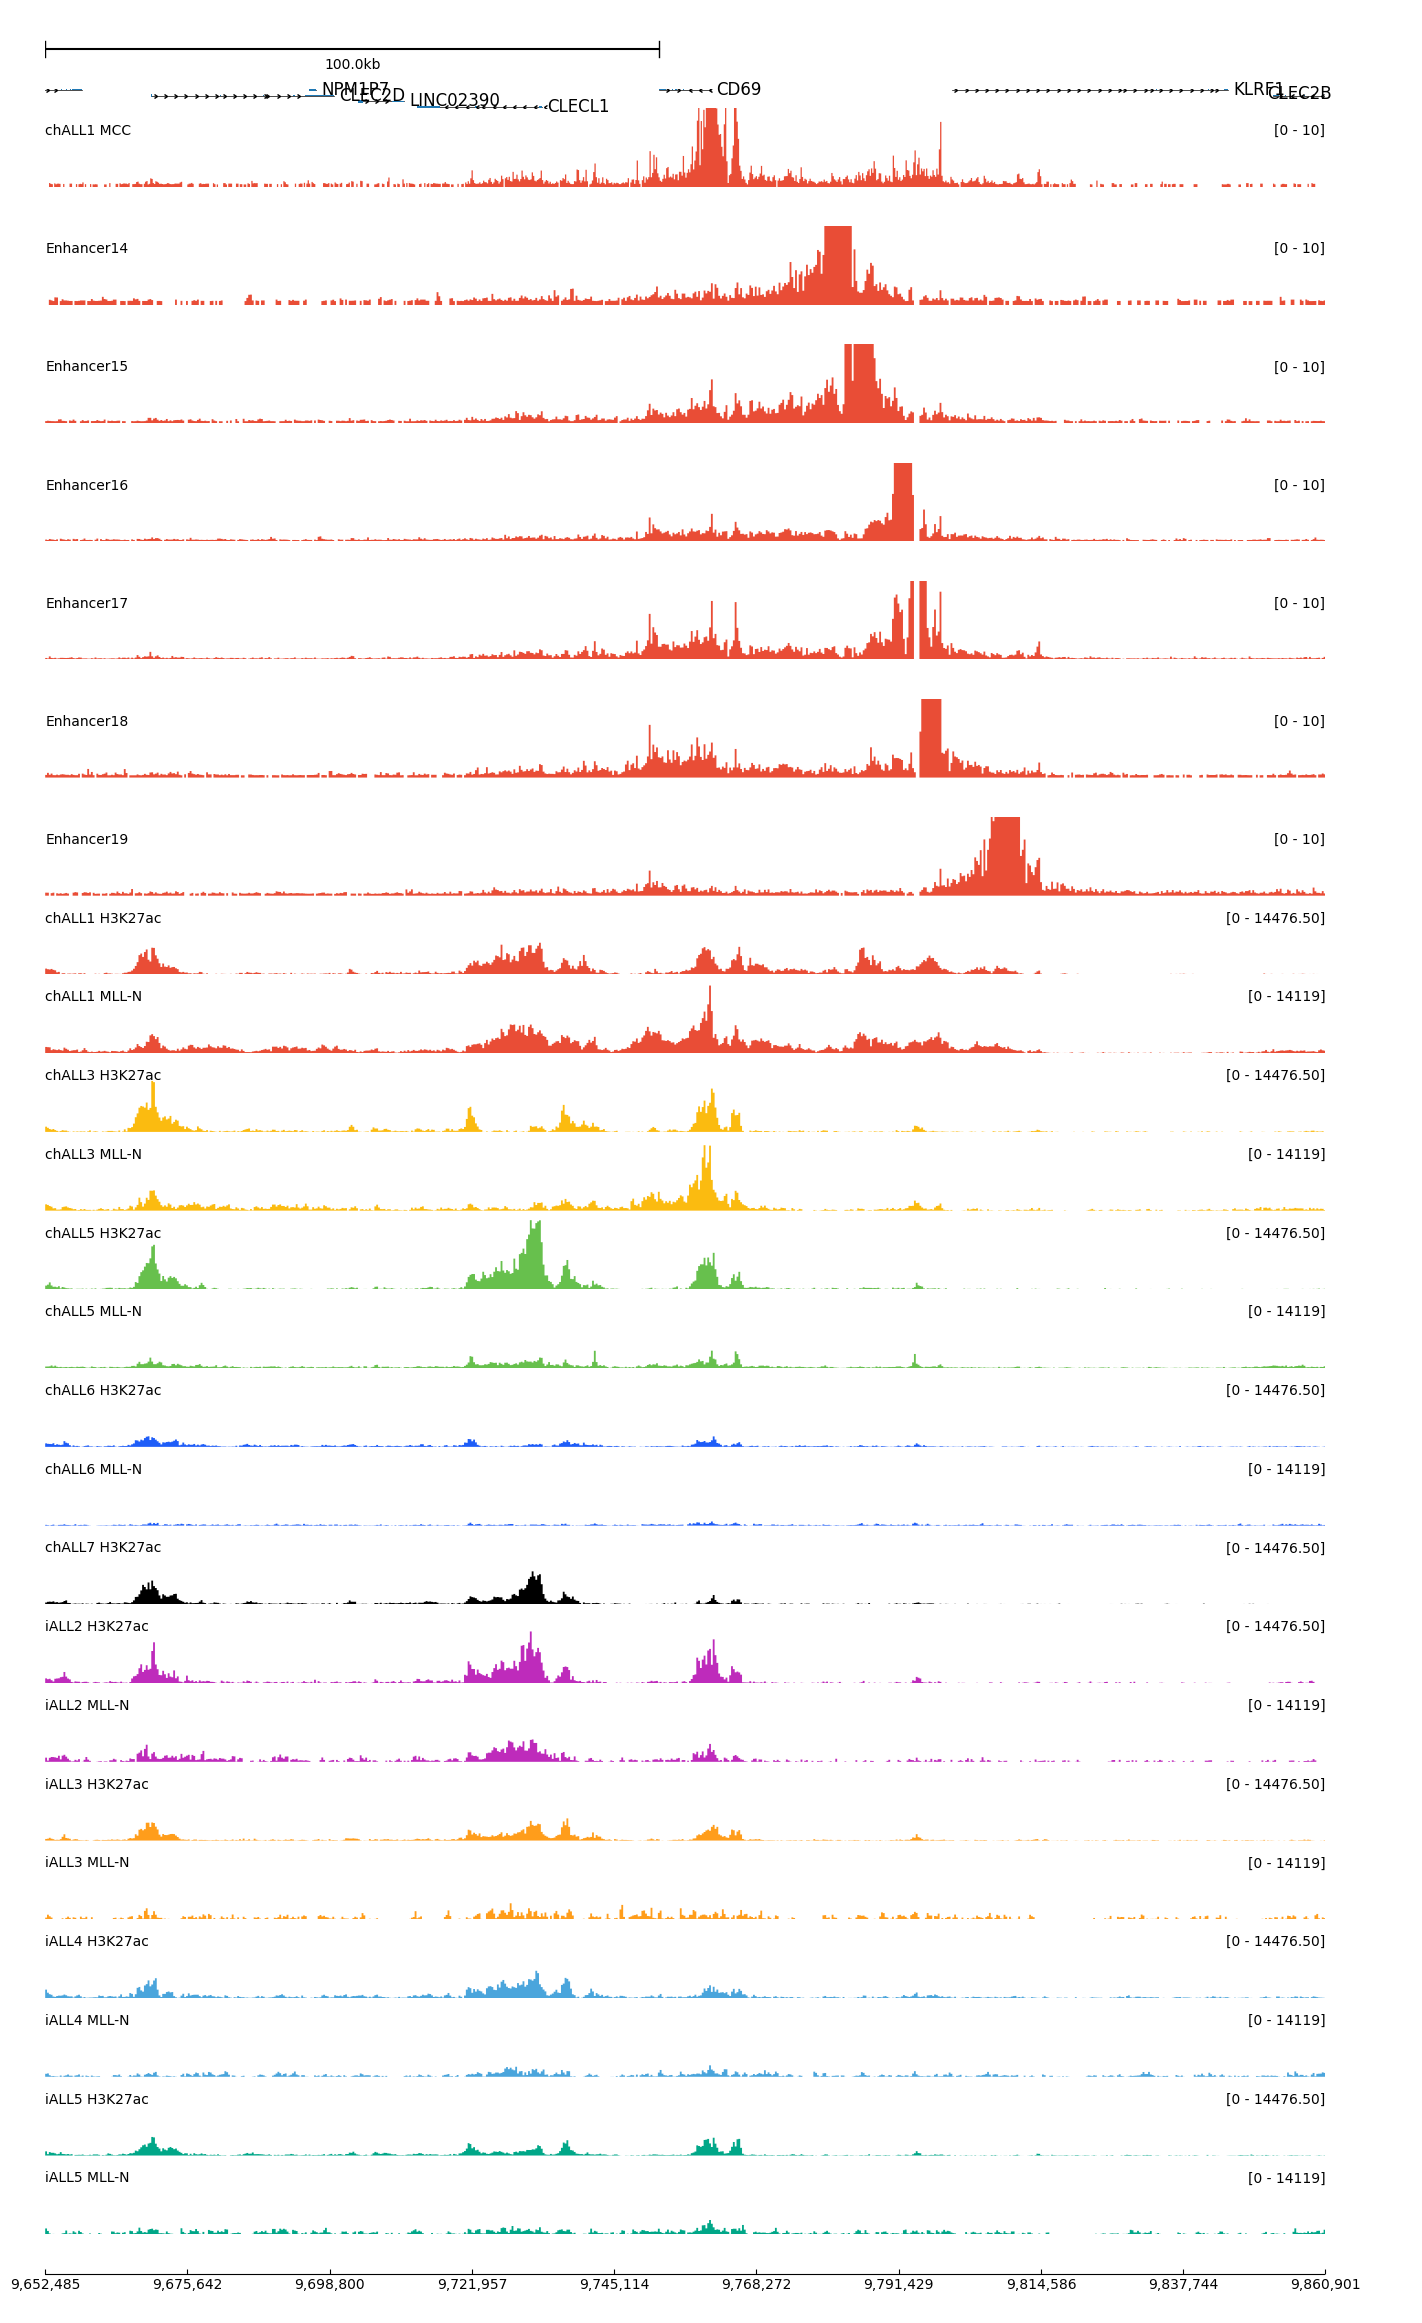

In [35]:
VIEWPOINT = "CD69"

fig = make_figure(VIEWPOINT, chip_tracks, mcc_tracks, patient_sample_colors, None, min_gene_length=int(1e3), mcc_max_value=10)
f = fig.plot_gene(VIEWPOINT, "hg38", extend=int(1e5))
f

2025-05-08 16:10:40.338 | DEBUG    | plotnado.api.genes:__get_length_w:49 - len of w set to: 2945.2612702366127 bp
2025-05-08 16:10:40.425 | DEBUG    | plotnado.api.genes:plot_genes:206 - ylim 330.0,0


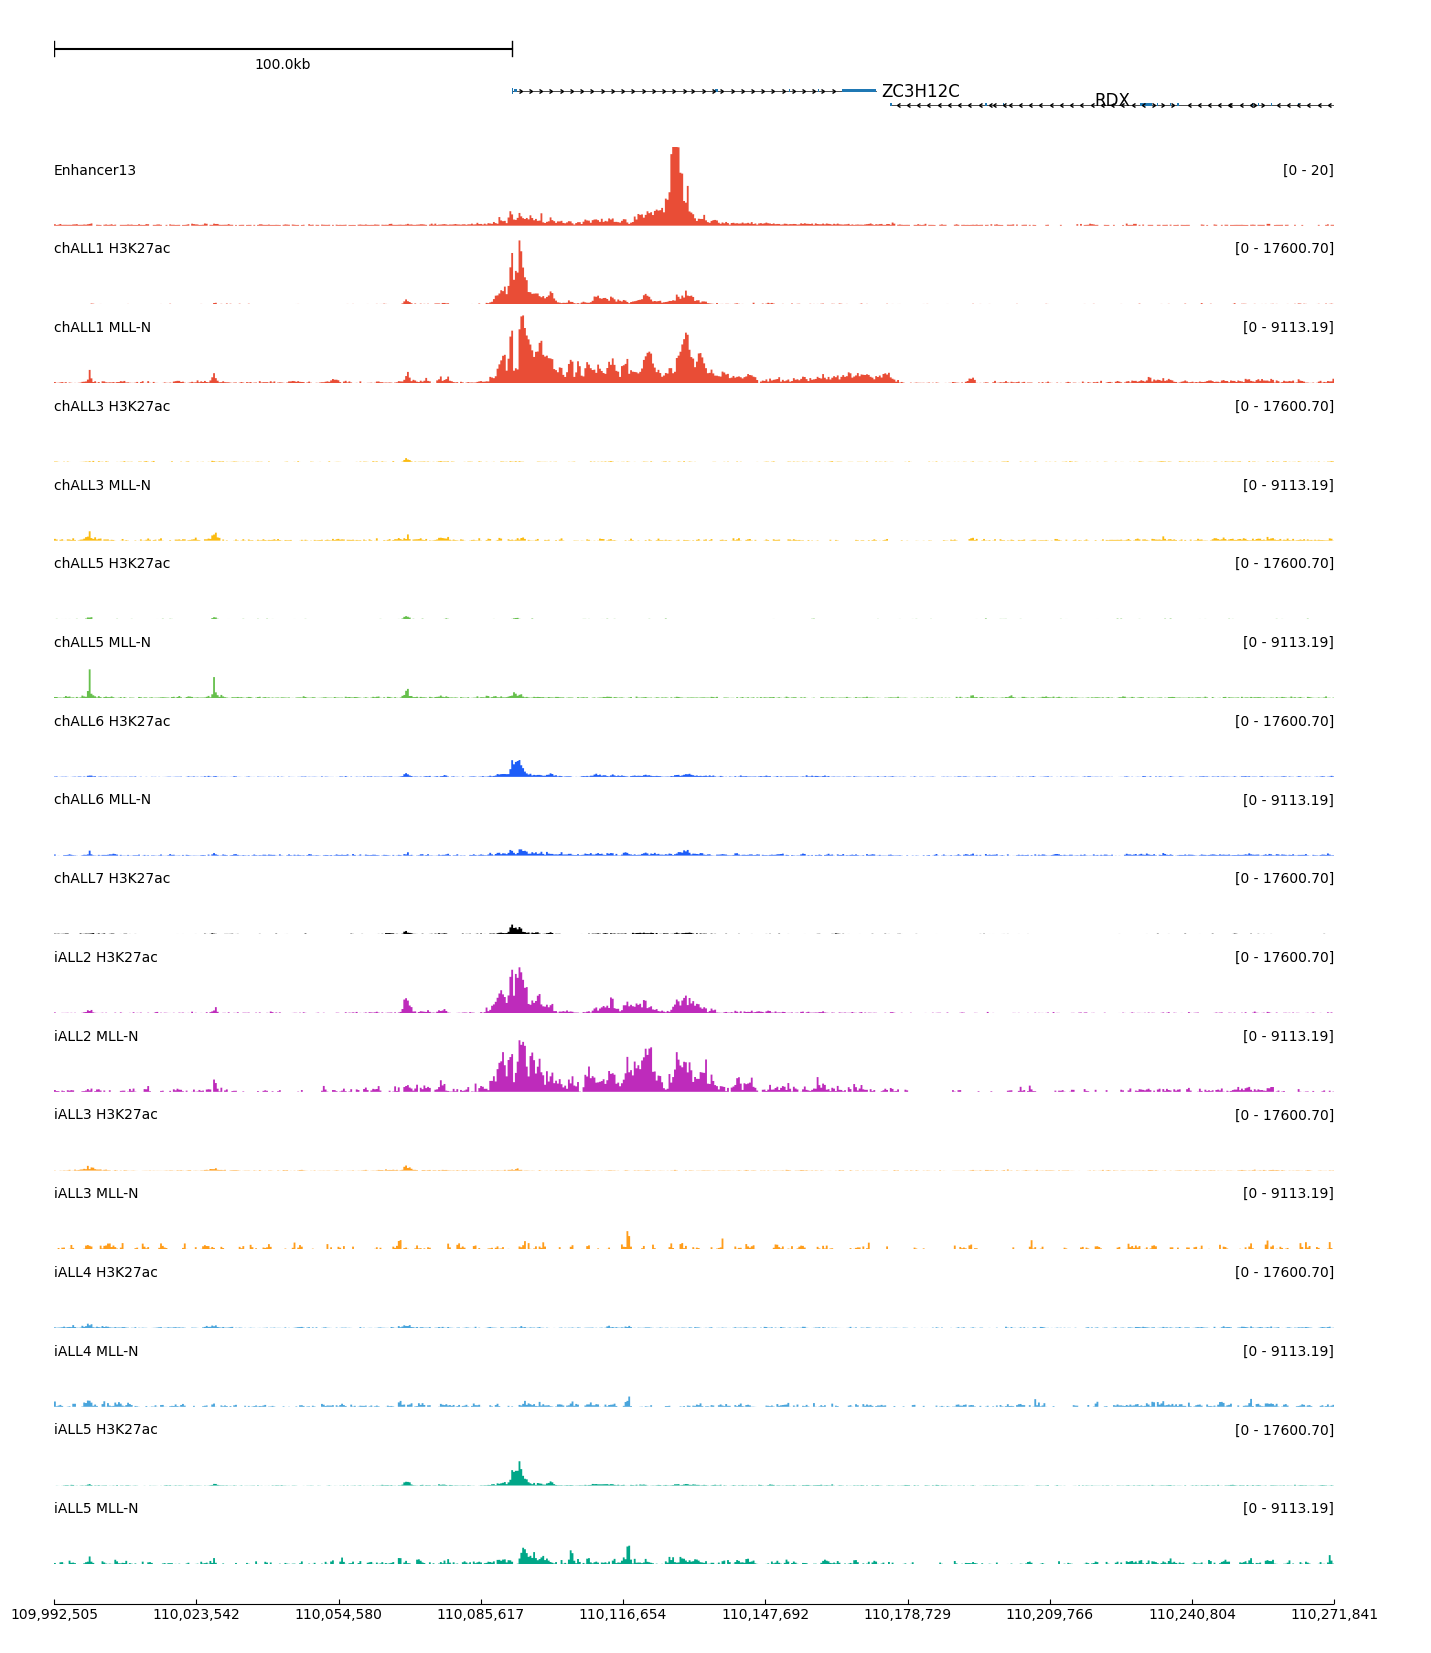

In [36]:
VIEWPOINT = 'ZC3H12C'
fig = make_figure(VIEWPOINT, chip_tracks, None, patient_sample_colors, None, min_gene_length=int(1e3), mcc_max_value=20)
f = fig.plot_gene(VIEWPOINT, "hg38", extend=int(1e5))
f

2025-05-08 16:10:44.850 | DEBUG    | plotnado.api.genes:__get_length_w:49 - len of w set to: 6692.715483603156 bp
2025-05-08 16:10:45.331 | DEBUG    | plotnado.api.genes:plot_genes:206 - ylim 789.9999999999999,0


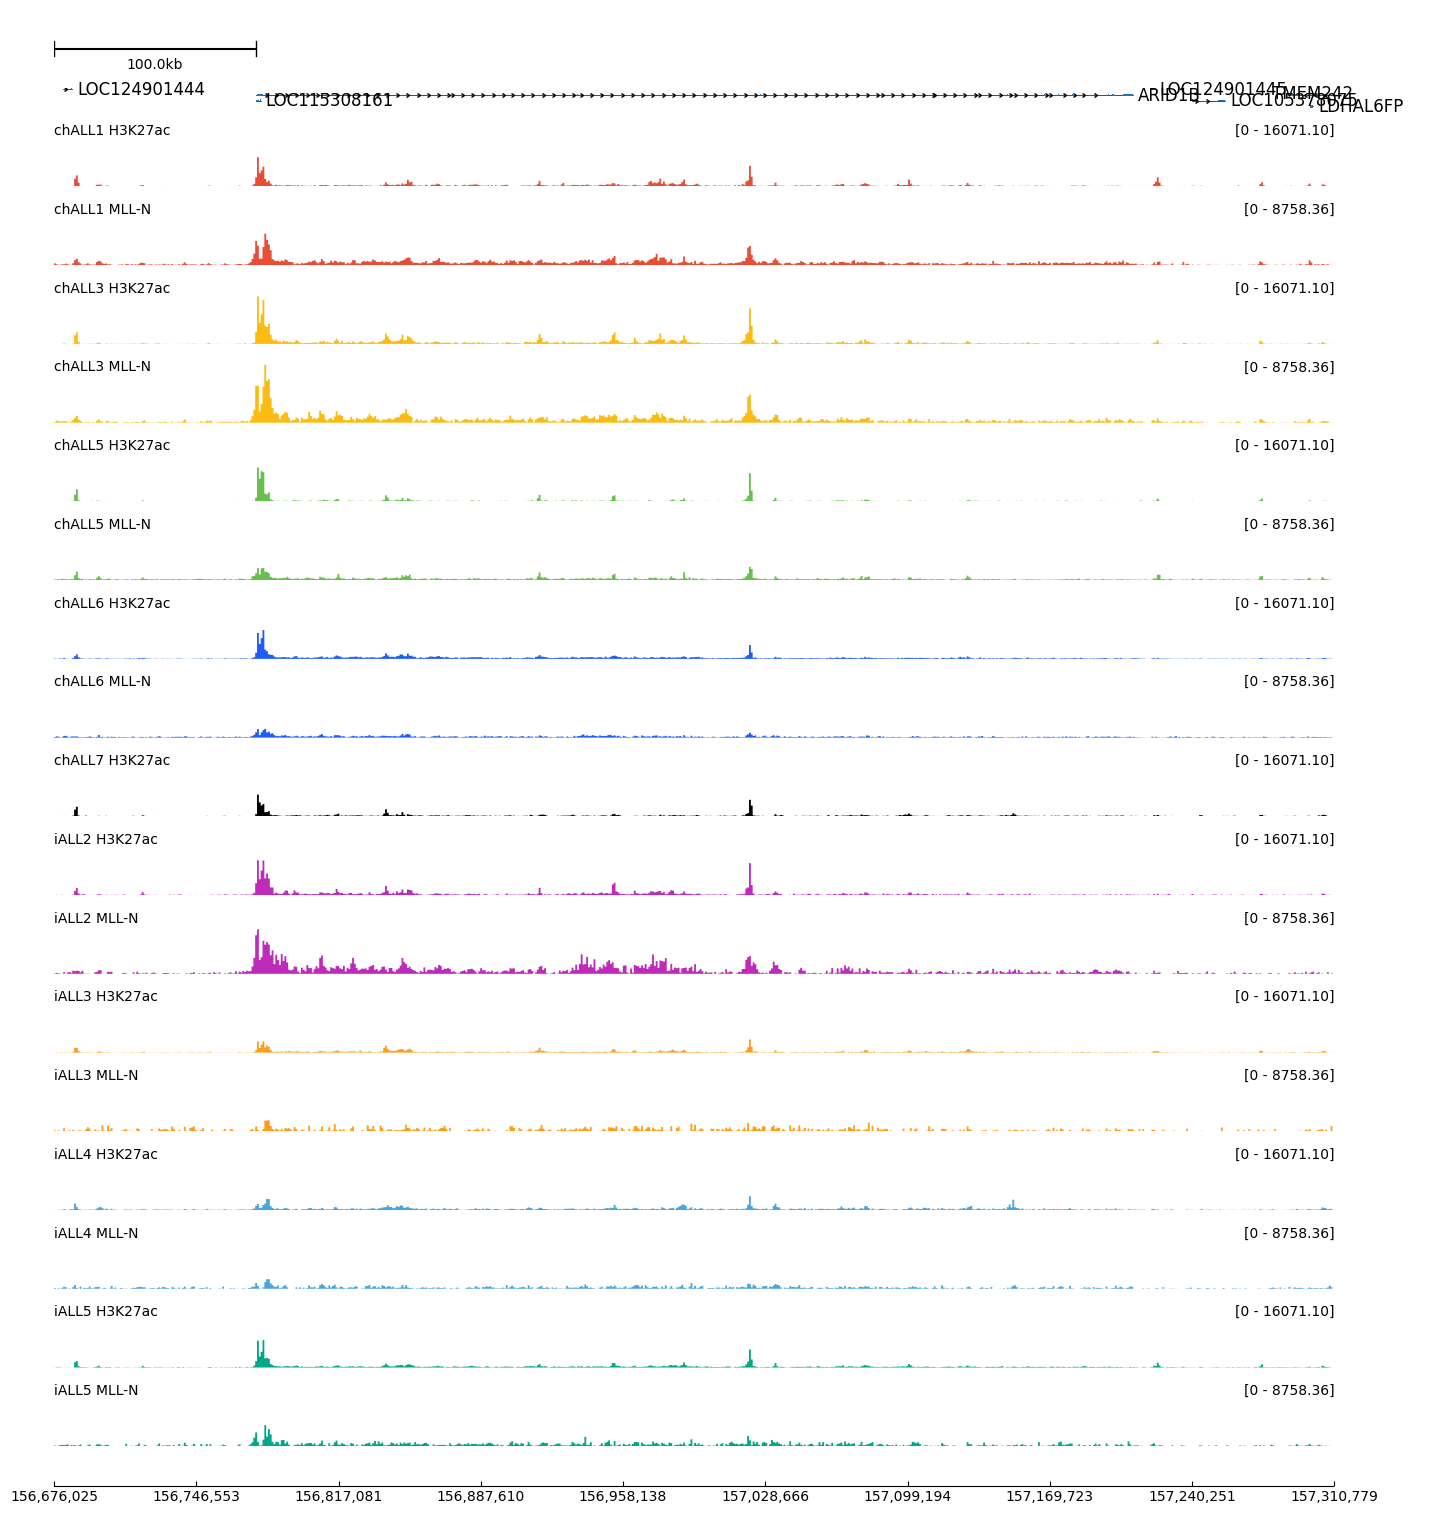

In [37]:
VIEWPOINT = 'ARID1B'
fig = make_figure(VIEWPOINT, chip_tracks, None, patient_sample_colors, None, min_gene_length=int(1e3), mcc_max_value=20)
f = fig.plot_gene(VIEWPOINT, "hg38", extend=int(1e5))
f

# Main text figures

For the main text figures plot:

* SEM MCC track (if available)
* Promoter track
* Enhancer x Number of enhancers in range
* SEM H3K27ac
* SEM KMT2A
* SEM AFF1
* chALL1 H3K27ac
* chALL1 KMT2A

In [81]:
chip_tracks_main_figure = chip_tracks.query("patient_name == 'chALL1'")
chip_tracks_main_figure = pd.concat([df_archive.assign(patient_name='SEM'), chip_tracks_main_figure])
chip_tracks_main_figure = chip_tracks_main_figure.assign(
    antibody=lambda df: df.antibody.map(
        {
            'MLLN': 'KMT2A-N',
            'H3K27AC': 'H3K27ac',
            'AF4C': 'AFF1-C',
            'MLL-N': 'KMT2A-N',
            'H3K27ac': 'H3K27ac',

        }
    )
).assign(
    # Set order of the antibody
    antibody=lambda df: pd.Categorical(
        df.antibody, categories=["H3K27ac", "KMT2A-N", "AFF1-C"], ordered=True
    ),
    patient=lambda df: pd.Categorical(
        df.patient_name,
        categories=["SEM", "chALL1"],
        ordered=True,
    ),
).sort_values(
    ["antibody", "patient"]
).reset_index(drop=True)

chip_tracks_main_figure

,path,name,antibody,patient_name,assay,patient,is_xeno
0,/ceph/project/milne_group/shared/seqnado_archi...,sem-h3k27ac_h3k27ac,H3K27ac,SEM,NaN,SEM,NaN
1,/home/a/asmith/project_milne_group/Projects/20...,chALL-26754-CM_H3K27ac,H3K27ac,chALL1,CM,chALL1,False
2,/ceph/project/milne_group/shared/seqnado_archi...,sem-mlln_mlln,KMT2A-N,SEM,NaN,SEM,NaN
3,/home/a/asmith/project_milne_group/Projects/20...,chALL-26754-CM_MLLN,KMT2A-N,chALL1,CM,chALL1,False
4,/ceph/project/milne_group/shared/seqnado_archi...,sem-af4c_af4c,AFF1-C,SEM,NaN,SEM,NaN


In [98]:
figures = dict()

2025-05-08 16:51:57.912 | DEBUG    | plotnado.api.genes:__get_length_w:49 - len of w set to: 2517.278123702781 bp
2025-05-08 16:51:57.938 | DEBUG    | plotnado.api.genes:plot_genes:206 - ylim 330.0,0


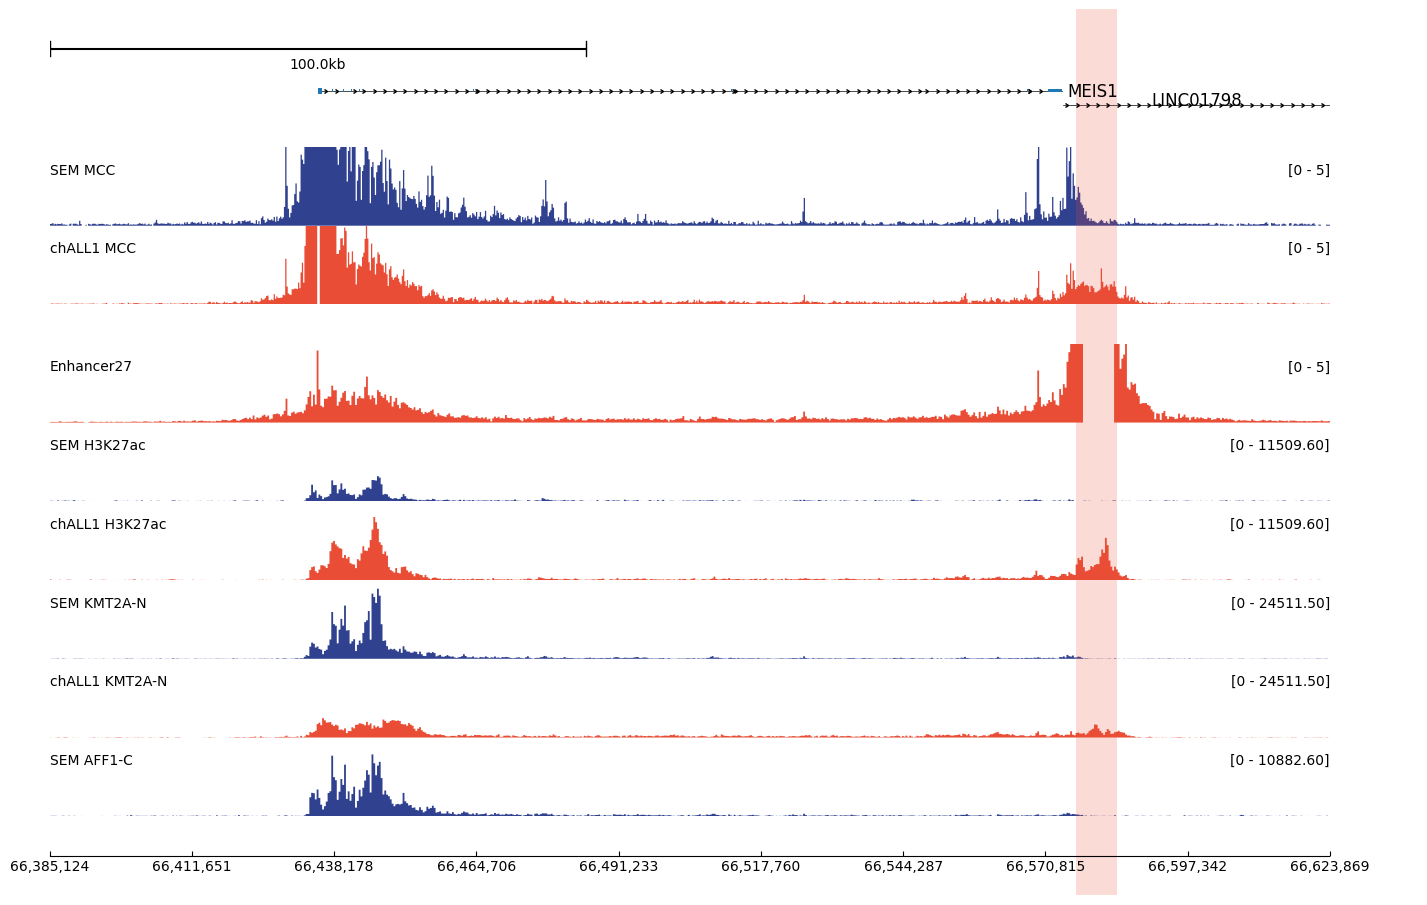

In [99]:
VIEWPOINT = "MEIS1"
fig = make_figure(VIEWPOINT, 
                  chip_tracks=chip_tracks_main_figure,
                  mcc_tracks=mcc_tracks, 
                  colors=patient_sample_colors, 
                  highlight=highlight)

f = fig.plot_gene(VIEWPOINT, "hg38", extend=int(5e4))
figures[VIEWPOINT] = f
f

[ERROR:base.py:264 -       plot_coverages()] Error occured when plot track's coverage:
	track name: ScaleBar.46
	track type:<class 'plotnado.api.tracks.ScaleBar'>
	coverage name: HighlightsFromFile.1
	cov type: <class 'plotnado.api.tracks.HighlightsFromFile'>
	Error: <class 'KeyError'> '6'
[ERROR:base.py:269 -       plot_coverages()] '6'
Traceback (most recent call last):
  File "/ceph/project/milne_group/asmith/software/mambaforge/envs/ma4_th/lib/python3.10/site-packages/coolbox/core/track/base.py", line 262, in plot_coverages
    cov.plot(ax, copy(gr), gr2=copy(gr2))
  File "/ceph/project/milne_group/asmith/Projects/plotnado/plotnado/api/tracks.py", line 1415, in plot
    regions = self.fetch_data(gr, **kwargs)
  File "/ceph/project/milne_group/asmith/software/mambaforge/envs/ma4_th/lib/python3.10/site-packages/coolbox/core/coverage/highlights.py", line 24, in fetch_data
    self.interval_tree[gr.chrom][gr.start - 10000 : gr.end + 10000]
KeyError: '6'
2025-05-08 16:52:11.540 | DEBUG 

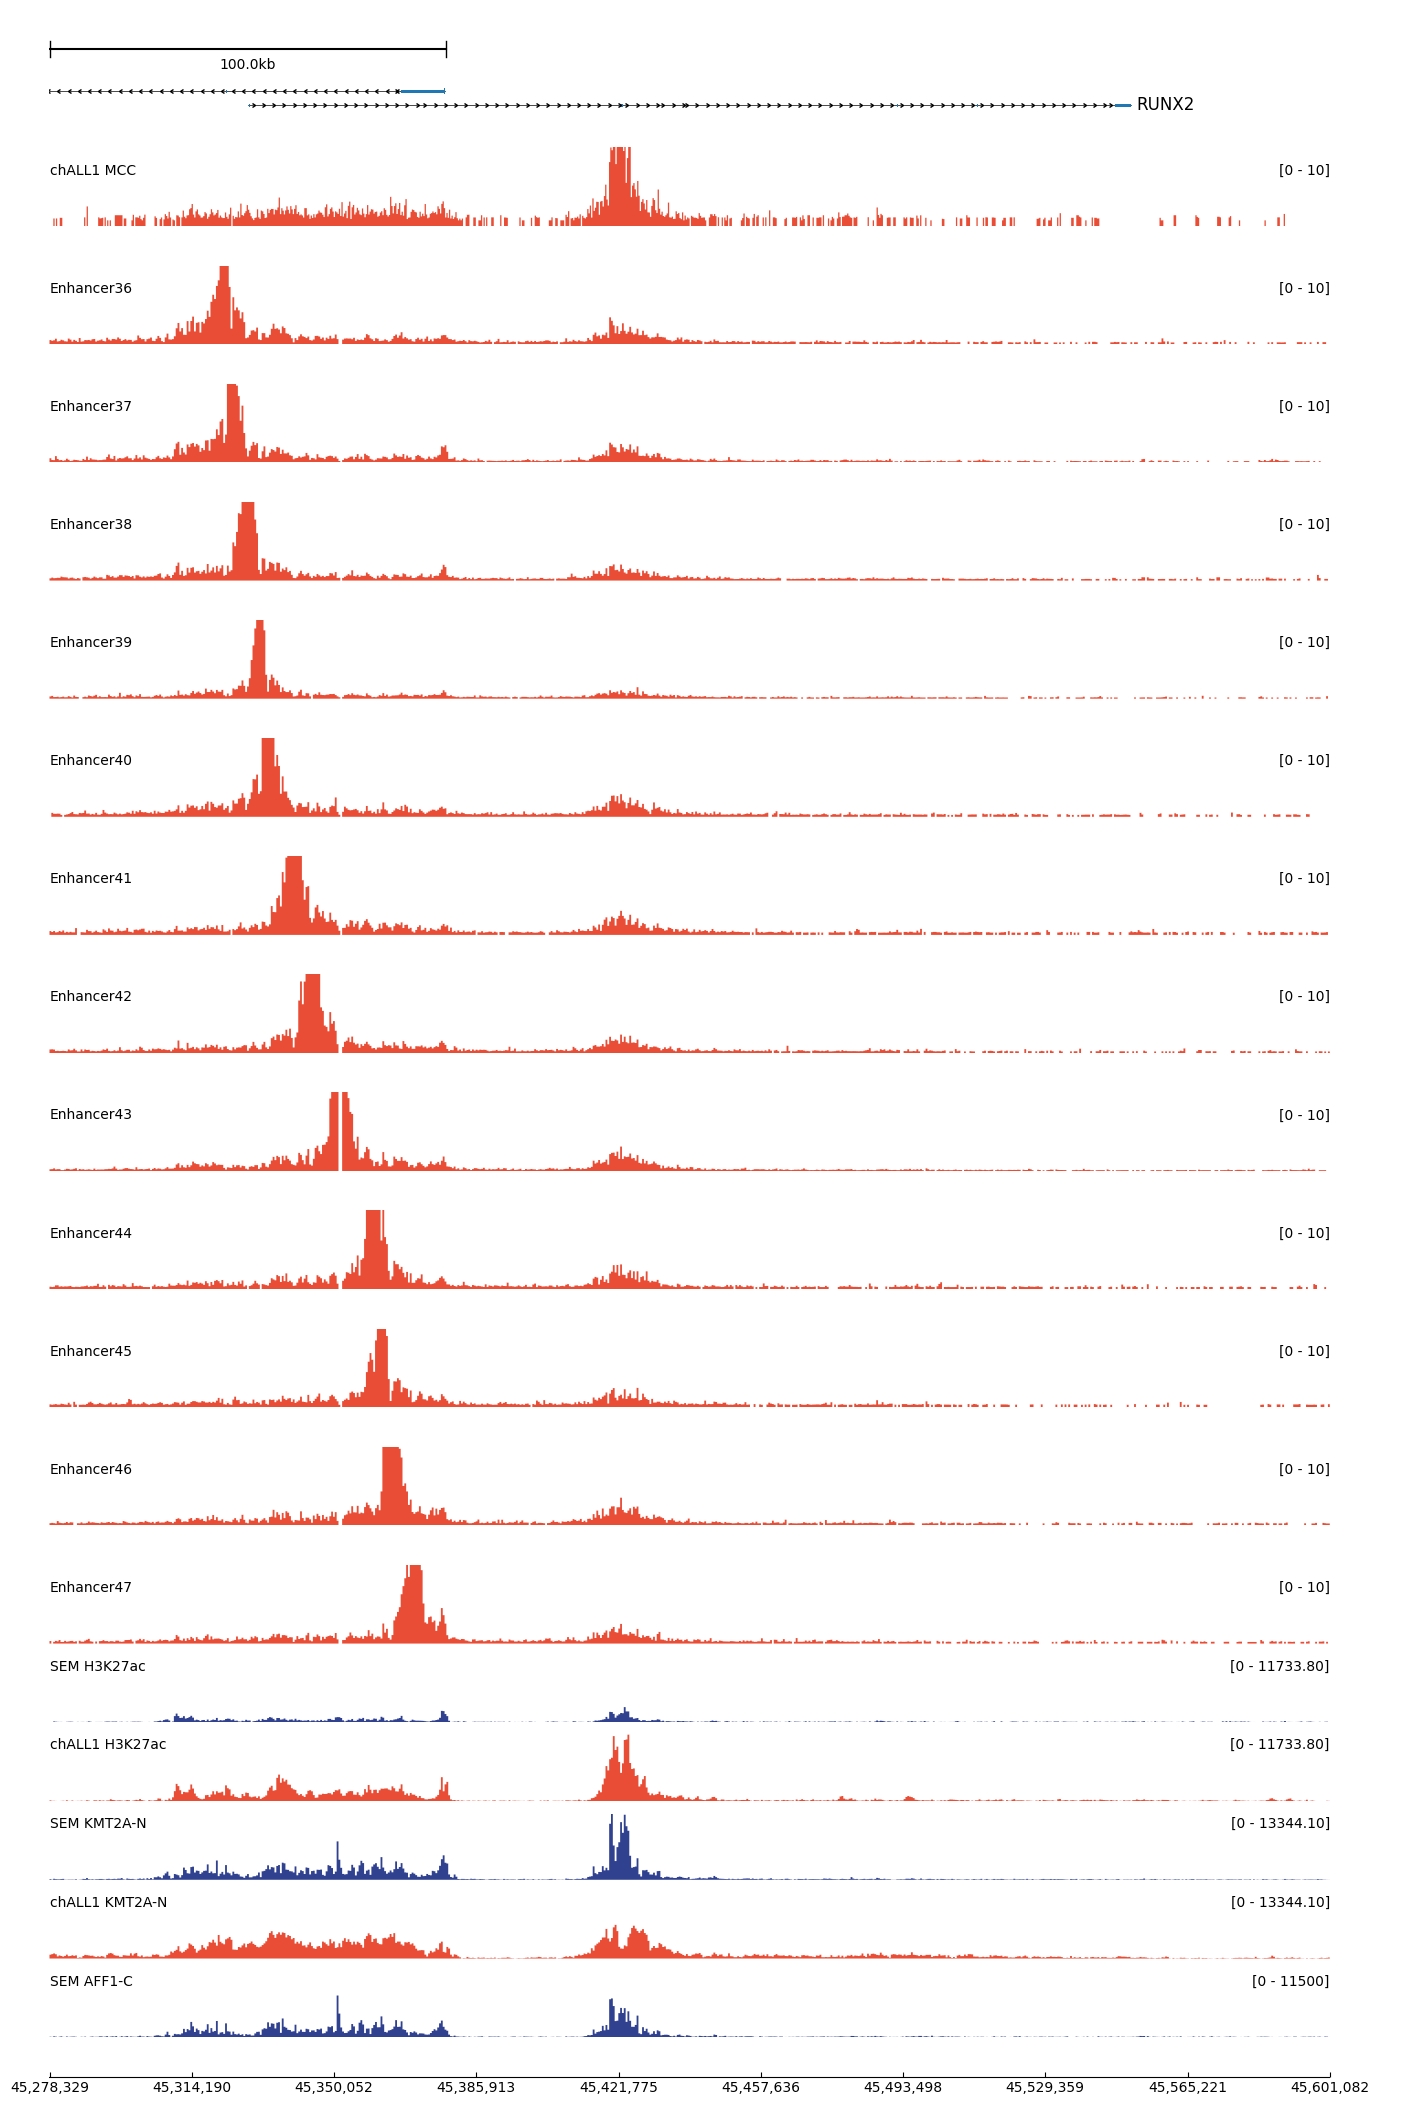

In [100]:
VIEWPOINT = "RUNX2"
fig = make_figure(VIEWPOINT, 
                  chip_tracks=chip_tracks_main_figure,
                  mcc_tracks=mcc_tracks, 
                  colors=patient_sample_colors, 
                  highlight=highlight,
                  mcc_max_value=10)

f = fig.plot_gene(VIEWPOINT, "hg38", extend=int(5e4))
figures[VIEWPOINT] = f
f

2025-05-08 16:52:31.379 | DEBUG    | plotnado.api.genes:__get_length_w:49 - len of w set to: 2197.495392278954 bp
2025-05-08 16:52:31.483 | DEBUG    | plotnado.api.genes:plot_genes:206 - ylim 789.9999999999999,0


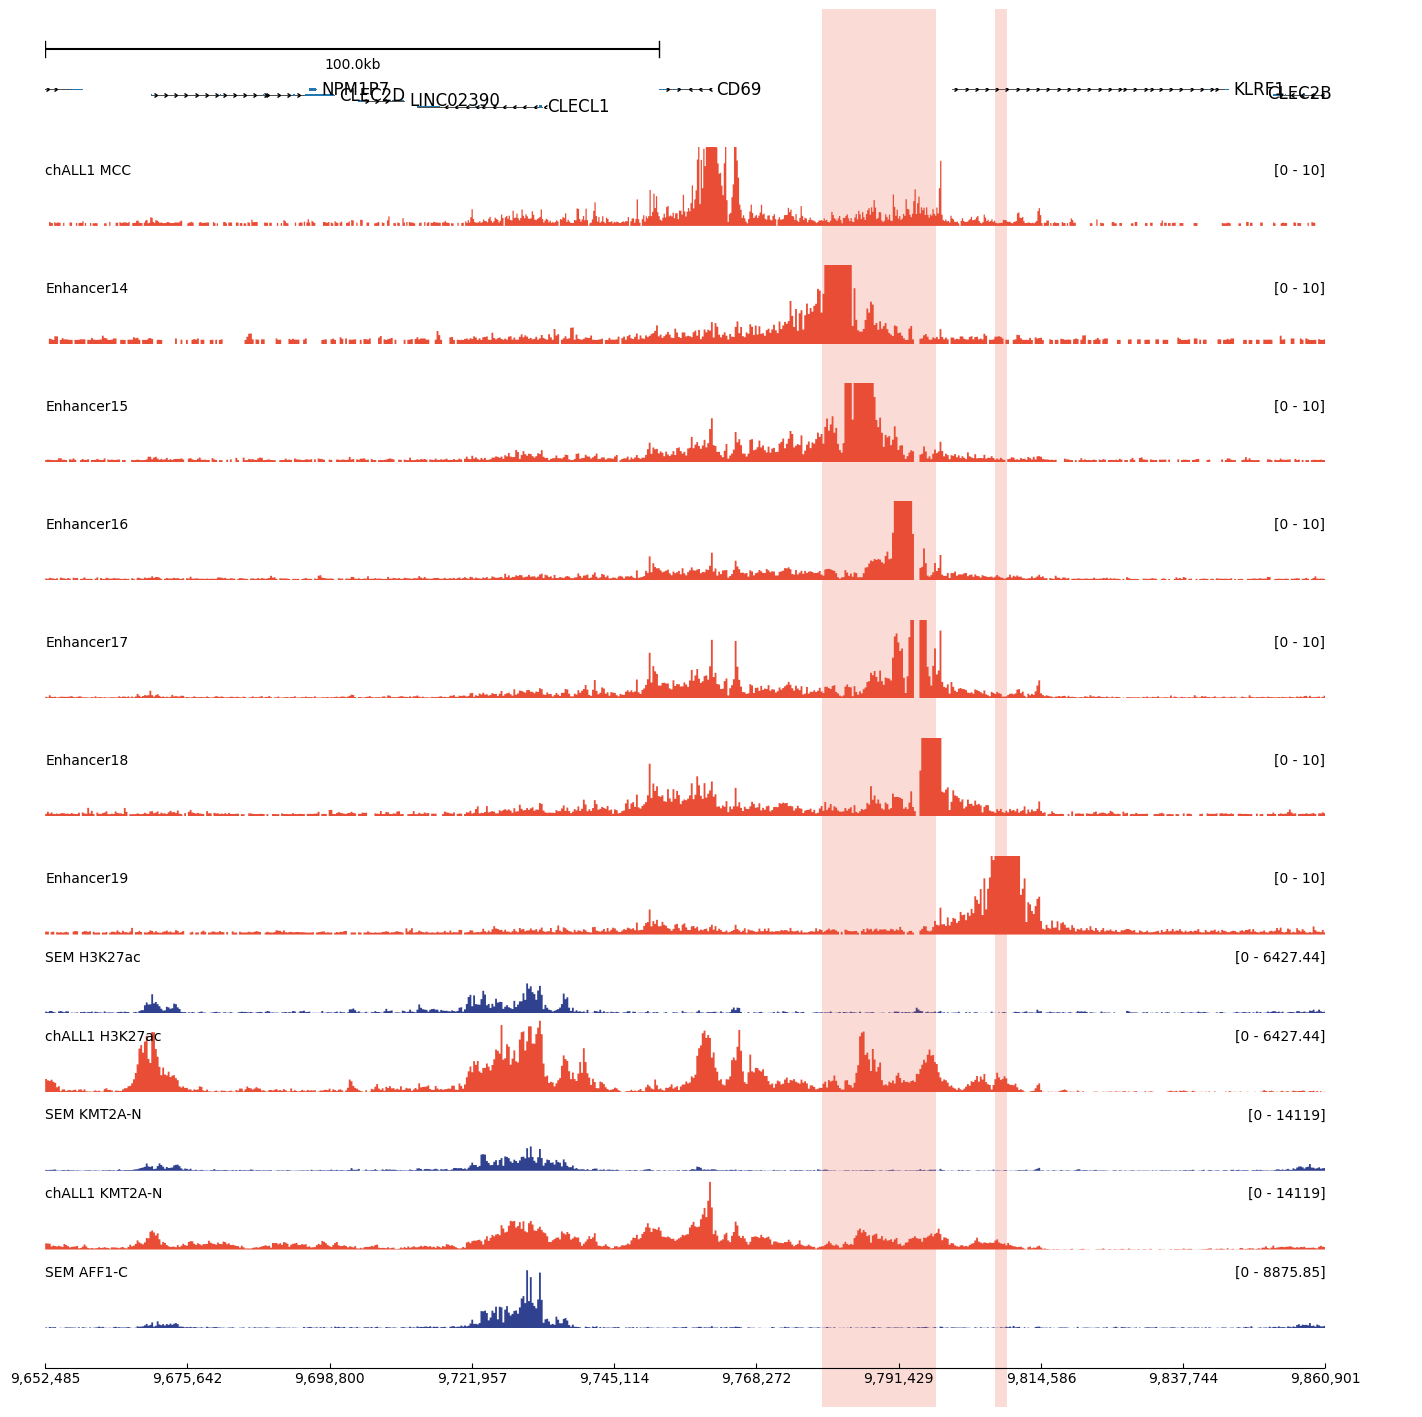

In [101]:
VIEWPOINT = "CD69"
fig = make_figure(VIEWPOINT, 
                  chip_tracks=chip_tracks_main_figure,
                  mcc_tracks=mcc_tracks, 
                  colors=patient_sample_colors, 
                  highlight=highlight,
                  min_gene_length=int(1e3),
                  mcc_max_value=10)

f = fig.plot_gene(VIEWPOINT, "hg38", extend=int(1e5))
figures[VIEWPOINT] = f
f

### Export figures

In [ ]:
outdir = pathlib.Path("main_text_figures")

for viewpoint, fig in figures.items():
    fig.savefig(
        f"figures/{